In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno

from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
import re


import matplotlib.pyplot as plt
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시


In [3]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine

In [4]:
# 와인 데이터셋 로드
wine = load_wine()
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [5]:
x = wine.data
y = wine.target

In [6]:
# 특성 데이터 표준화
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [7]:
x_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [8]:
# PCA 적용 (2차원으로 축소)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

# 결과 출력
print(f"주성분들의 분산 비율: {pca.explained_variance_ratio_}")
print(f"누적 분산 비율: {np.cumsum(pca.explained_variance_ratio_)}")

주성분들의 분산 비율: [0.36198848 0.1920749 ]
누적 분산 비율: [0.36198848 0.55406338]


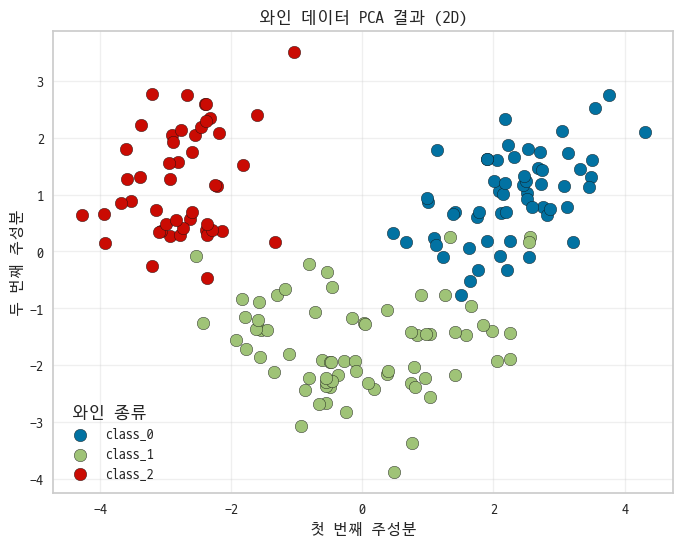

주성분별 특성 기여도:
[[ 0.1443294  -0.24518758 -0.00205106 -0.23932041  0.14199204  0.39466085
   0.4229343  -0.2985331   0.31342949 -0.0886167   0.29671456  0.37616741
   0.28675223]
 [ 0.48365155  0.22493093  0.31606881 -0.0105905   0.299634    0.06503951
  -0.00335981  0.02877949  0.03930172  0.52999567 -0.27923515 -0.16449619
   0.36490283]]


In [9]:
# 시각화
plt.figure(figsize=(8, 6))

for i, name in enumerate(wine.target_names):
    plt.scatter(
        x_pca[y == i, 0],
        x_pca[y == i, 1],
        label=name,
        s=80,
        edgecolor='k'
    )

plt.title("와인 데이터 PCA 결과 (2D)")
plt.xlabel("첫 번째 주성분")
plt.ylabel("두 번째 주성분")
plt.legend(title="와인 종류")
plt.grid(alpha=0.3)
plt.show()

# 주성분 기여도
print("주성분별 특성 기여도:")
print(pca.components_)

주성분 행렬 (각 주성분의 특성 기여도):
주성분 1:
  특성 1 (alcohol): 0.1443
  특성 2 (malic_acid): -0.2452
  특성 3 (ash): -0.0021
  특성 4 (alcalinity_of_ash): -0.2393
  특성 5 (magnesium): 0.1420
  특성 6 (total_phenols): 0.3947
  특성 7 (flavanoids): 0.4229
  특성 8 (nonflavanoid_phenols): -0.2985
  특성 9 (proanthocyanins): 0.3134
  특성 10 (color_intensity): -0.0886
  특성 11 (hue): 0.2967
  특성 12 (od280/od315_of_diluted_wines): 0.3762
  특성 13 (proline): 0.2868
  -> 설명된 분산 비율: 0.3620

주성분 2:
  특성 1 (alcohol): 0.4837
  특성 2 (malic_acid): 0.2249
  특성 3 (ash): 0.3161
  특성 4 (alcalinity_of_ash): -0.0106
  특성 5 (magnesium): 0.2996
  특성 6 (total_phenols): 0.0650
  특성 7 (flavanoids): -0.0034
  특성 8 (nonflavanoid_phenols): 0.0288
  특성 9 (proanthocyanins): 0.0393
  특성 10 (color_intensity): 0.5300
  특성 11 (hue): -0.2792
  특성 12 (od280/od315_of_diluted_wines): -0.1645
  특성 13 (proline): 0.3649
  -> 설명된 분산 비율: 0.1921



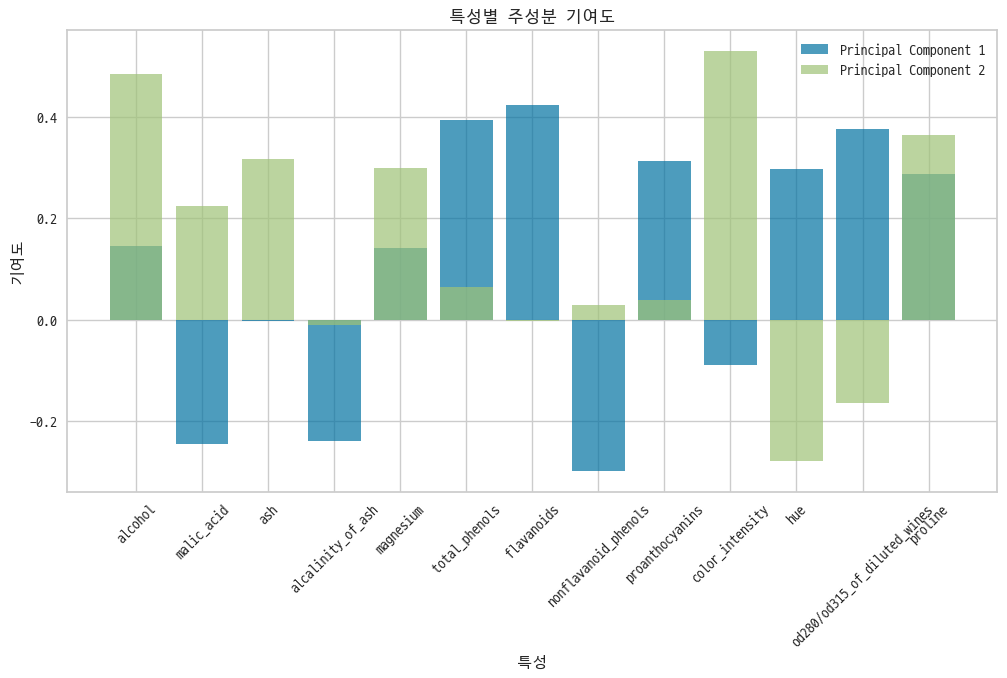

In [10]:
# 주성분과 분산 비율 정보 가져오기
components = pca.components_
explained_variance = pca.explained_variance_ratio_
feature_names = wine.feature_names

# 주성분의 기여도 출력
print("주성분 행렬 (각 주성분의 특성 기여도):")
for i, component in enumerate(components):
    print(f"주성분 {i + 1}:")
    for j, contribution in enumerate(component):
        print(f"  특성 {j + 1} ({feature_names[j]}): {contribution:.4f}")
    print(f"  -> 설명된 분산 비율: {explained_variance[i]:.4f}")
    print()


plt.figure(figsize=(12, 6))

# 첫 번째 주성분
plt.bar(wine.feature_names, components[0], alpha=0.7, label="Principal Component 1")

# 두 번째 주성분
plt.bar(wine.feature_names, components[1], alpha=0.7, label="Principal Component 2")

plt.title("특성별 주성분 기여도")
plt.xlabel("특성")
plt.ylabel("기여도")
plt.legend()
plt.xticks(rotation=45)  # x축 레이블 회전
plt.show()

In [11]:
#### 주성분의 누적분산비율로 정하기

# 데이터셋 로드
wine = load_wine()
x = wine.data

# 데이터 표준화
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


# PCA를 전체 분산의 95%를 설명하도록 설정
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(x_scaled)

# 선택된 주성분 개수 확인
print(f"선택된 주성분 개수: {pca.n_components_}")
print(f"주성분 분산 비율: {pca.explained_variance_ratio_}")

feature_names = wine.feature_names
components = pca.components_

# 각 주성분의 분산 설명 비율 출력
explained_variance_ratio = pca.explained_variance_ratio_
for i, ratio in enumerate(explained_variance_ratio):
    print(f"주성분 {i+1}의 분산 설명 비율: {ratio:.4f}")

# 누적 분산 비율 출력
cumulative_variance = explained_variance_ratio.cumsum()
print("\n누적 분산 비율:")
for i, cum_ratio in enumerate(cumulative_variance):
    print(f"주성분 1~{i+1}까지의 누적 분산 비율: {cum_ratio:.4f}")

선택된 주성분 개수: 10
주성분 분산 비율: [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019]
주성분 1의 분산 설명 비율: 0.3620
주성분 2의 분산 설명 비율: 0.1921
주성분 3의 분산 설명 비율: 0.1112
주성분 4의 분산 설명 비율: 0.0707
주성분 5의 분산 설명 비율: 0.0656
주성분 6의 분산 설명 비율: 0.0494
주성분 7의 분산 설명 비율: 0.0424
주성분 8의 분산 설명 비율: 0.0268
주성분 9의 분산 설명 비율: 0.0222
주성분 10의 분산 설명 비율: 0.0193

누적 분산 비율:
주성분 1~1까지의 누적 분산 비율: 0.3620
주성분 1~2까지의 누적 분산 비율: 0.5541
주성분 1~3까지의 누적 분산 비율: 0.6653
주성분 1~4까지의 누적 분산 비율: 0.7360
주성분 1~5까지의 누적 분산 비율: 0.8016
주성분 1~6까지의 누적 분산 비율: 0.8510
주성분 1~7까지의 누적 분산 비율: 0.8934
주성분 1~8까지의 누적 분산 비율: 0.9202
주성분 1~9까지의 누적 분산 비율: 0.9424
주성분 1~10까지의 누적 분산 비율: 0.9617


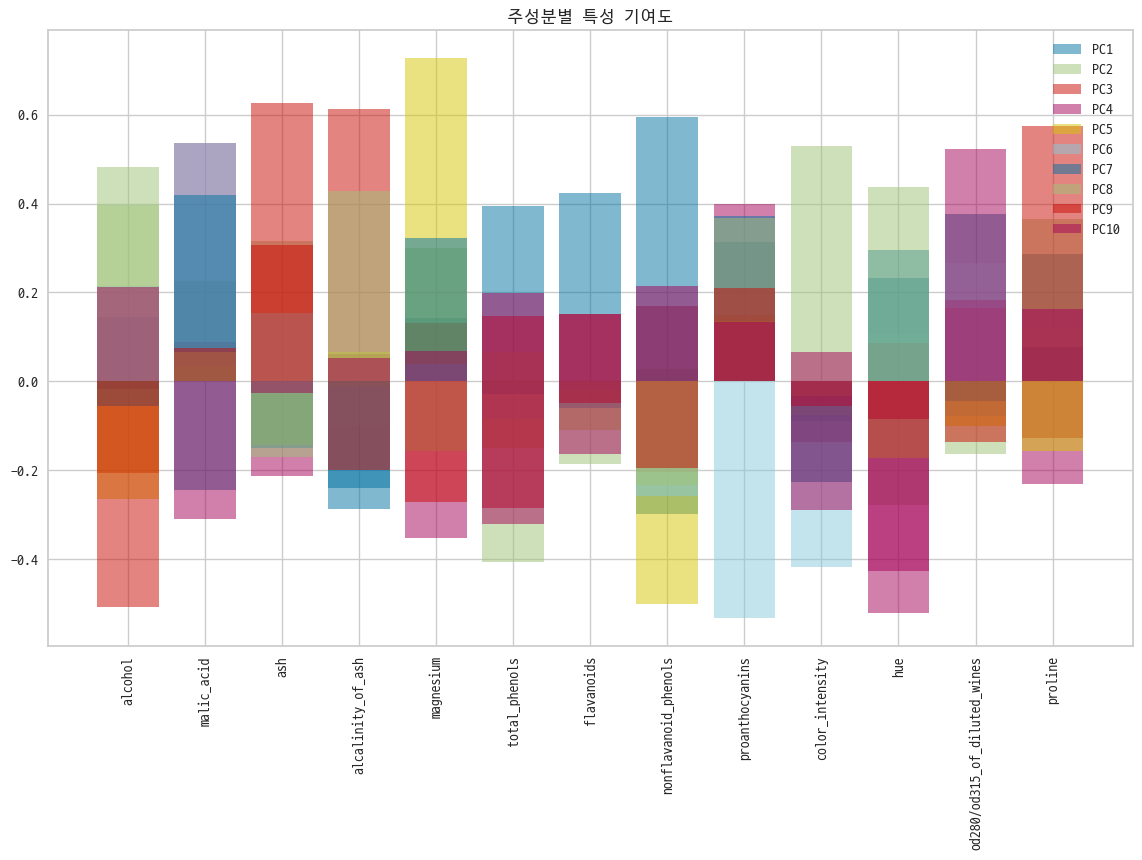

In [ ]:
plt.figure(figsize=(14, 8))

for i in range(10):  # 주성분 10개, 더 필요하면 성분개수까지 늘릴 수 있다
    plt.bar(
        range(len(feature_names)),  # x축: 특성 인덱스
        components[i],             # y축: 각 특성의 기여도
        alpha=0.5,                 # 투명도
        label=f"PC{i+1}"           # 범례 라벨
    )

plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.title("주성분별 특성 기여도")
plt.legend(loc='upper right')
plt.show()